# Satellite data puller: GOES + EarthCARE

EarthCARE downloads also need the one-time ESA MAAP credentials setup: https://tropos-rsd.github.io/earthcarekit/setup/

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Proj

from goes2go import GOES
import earthcarekit as eck

from satpy import Scene
from pyresample.utils.cf import load_cf_area

## Where and when: `Region`, `TimeRange`, `Availability`

In [2]:
@dataclass
class Region:
    """Lat/lon bounding box in degrees.
    Boxes crossing the antimeridian must be split into two.
    """

    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float

    def __post_init__(self):
        if not (-90 <= self.lat_min < self.lat_max <= 90):
            raise ValueError("Need -90 <= lat_min < lat_max <= 90")
        if not (-180 <= self.lon_min < self.lon_max <= 180):
            raise ValueError("Need -180 <= lon_min < lon_max <= 180")

    @classmethod
    def from_center(cls, lat, lon, half_width_deg=2.0):
        """Square box around a point."""
        return cls(
            max(lat - half_width_deg, -90),
            min(lat + half_width_deg, 90),
            max(lon - half_width_deg, -180),
            min(lon + half_width_deg, 180),
        )

    def as_earthcarekit(self):
        """Order: (lat_south, lon_west, lat_north, lon_east)."""
        return self.lat_min, self.lon_min, self.lat_max, self.lon_max


@dataclass
class TimeRange:
    """Start/end timestamps. Accepts anything pandas can parse."""

    start: pd.Timestamp
    end: pd.Timestamp

    def __post_init__(self):
        self.start = pd.Timestamp(self.start)
        self.end = pd.Timestamp(self.end)

        if self.end <= self.start:
            raise ValueError("end must be after start")

@dataclass
class Availability:
    """Search-results table with convenient summary methods."""

    source: str
    table: pd.DataFrame

    @property
    def n_items(self):
        return len(self.table)

    @property
    def columns(self):
        return list(self.table.columns)

    def span(self, start_col, end_col):
        """Return the earliest start and latest end."""
        start = pd.to_datetime(self.table[start_col]).min()
        end = pd.to_datetime(self.table[end_col]).max()
        return start, end

    def __str__(self):
        if self.n_items == 0:
            return f"{self.source}: no data found"

        return (
            f"{self.source}: {self.n_items} items\n"
            f"Columns: {self.columns}"
        )

class SatelliteSource:
    """Common interface: ask what exists, then fetch it."""

    def availability(self, time, region=None):
        """List what's available without downloading."""
        raise NotImplementedError

    def fetch(self, time, region=None):
        """Download or load the data."""
        raise NotImplementedError

In [3]:
class EarthCareSource(SatelliteSource):
    """
    file_type: EarthCARE product, e.g. "ATL_NOM_1B" or "CPR_NOM_1B".
    baseline: Processor baseline, e.g. "BA"; None accepts any baseline.
    data_dir: Download folder; None uses earthcarekit's default.
    """

    name = "EarthCARE"

    def __init__(self, file_type, baseline=None, data_dir=None):
        self.file_type = file_type
        self.baseline = baseline
        self.data_dir = data_dir

    def _run(self, time, region, download):
        return eck.ecdownload(
            file_type=self.file_type,
            baseline=self.baseline,
            start_time=time.start,
            end_time=time.end,
            bounding_box=region.as_earthcarekit() if region else None,
            path_to_data=self.data_dir,
            is_download=download,
            return_results=True,
            verbose=False,
        )

    def availability(self, time, region=None):
        """List matching files without downloading."""
        df = self._run(time, region, download=False)

        if df is None:
            df = pd.DataFrame()

        return Availability(self.name, df)

    def fetch(self, time, region=None):
        """Download matching files and return the search-results table."""
        return self._run(time, region, download=True)

    def open(self, filepath):
        """Open a downloaded file; can be used as a context manager."""
        return eck.read_product(filepath)


class GOESSource(SatelliteSource):
    """
    satellite: GOES satellite number.
    product: Product name, e.g. "ABI-L2-MCMIPC".
    domain: "C", "F", "M1", or "M2".
    download: Whether to save raw files to disk.
    save_dir: Download folder; None uses goes2go's default.
    """

    name = "GOES"

    def __init__(
        self,
        satellite=19,
        product="ABI-L2-MCMIPC",
        domain="C",
        download=False,
        save_dir=None,
    ):
        self.satellite = satellite
        self.product = product
        self.domain = domain
        self.download = download
        self.save_dir = save_dir

    def _client(self):
        return GOES(
            satellite=self.satellite,
            product=self.product,
            domain=self.domain,
        )

    def availability(self, time, region=None):
        """List available files. The region is applied during fetch()."""
        df = self._client().df(time.start, time.end)
        return Availability(self.name, df)

    def fetch(self, time, region=None, download=None):
        """Load an xarray.Dataset and optionally crop it to a region.
        Passing download overrides the constructor setting for this call.
        """
        if download is None:
            download = self.download

        kwargs = {
            "return_as": "xarray",
            "download": download,
        }

        if download and self.save_dir:
            kwargs["save_dir"] = self.save_dir

        ds = self._client().timerange(
            start=time.start,
            end=time.end,
            **kwargs,
        )

        return self.crop(ds, region) if region else ds

    @staticmethod
    def crop(ds, region, variable="CMI_C13"):
        """Crop a GOES Dataset using Satpy."""
        if region is None:
            return ds
        
        area, _ = load_cf_area(ds, variable="goes_imager_projection",x="x",y="y") # Supply Satpy with the dataset's native grid geometry.

        # One band and one timestamp are enough to determine the crop
        grid = ds[variable]
        grid = grid.isel({dim: 0 for dim in grid.dims if dim not in ("x", "y")},drop=True).transpose("y", "x")

        scene = Scene()
        scene["grid"] = grid.assign_attrs(area=area)

        cropped = scene.crop(
            ll_bbox=(
                region.lon_min,
                region.lat_min,
                region.lon_max,
                region.lat_max,
            )
        )["grid"]

        assert cropped.sizes["x"] != 0 or cropped.sizes["y"] != 0, ValueError("Region does not overlap this GOES dataset.")
        return ds.sel(x=cropped.x, y=cropped.y)

## Test setup

In [4]:
COORDS = (42.05, -70.19)  # lat, lon (tip of the Cape, for the marker)
region = Region.from_center(*COORDS, half_width_deg=2)
window = TimeRange("2025-07-09 18:50:48", "2025-07-09 18:53:54.500")

In [5]:
SATELLITE = 19 # GOES-19 = GOES-East

goes = GOESSource(satellite=SATELLITE,
                  product="ABI-L2-MCMIPC", # get CONUS, all bands
                  domain="C",
                  download=True,
                  save_dir='../data')

avail = goes.availability(window, region)
avail.table

,file,product_mode,satellite,start,end,creation,product,mode_bands,mode,band
0,noaa-goes19/ABI-L2-MCMIPC/2025/190/18/OR_ABI-L...,ABI-L2-MCMIPC-M6,G19,2025-07-09 18:51:17.100,2025-07-09 18:53:54.500,2025-07-09 18:54:23.700,ABI-L2-MCMIPC,M6,6,None


## Fetch and crop

In [6]:
ds = goes.fetch(window, region)
ds

 👮🏻‍♂️ File already exists. Do not overwrite: ../data/noaa-goes19/ABI-L2-MCMIPC/2025/190/18/OR_ABI-L2-MCMIPC-M6_G19_s20251901851171_e20251901853545_c20251901854237.nc
📦 Finished downloading [1] files to [../data/noaa-goes19/ABI-L2-MCMIPC].
📖💽 Reading (1/1) file from LOCAL COPY [../data/noaa-goes19/ABI-L2-MCMIPC/2025/190/18/OR_ABI-L2-MCMIPC-M6_G19_s20251901851171_e20251901853545_c20251901854237.nc]. 

/Users/julianfontes/Library/Mobile Documents/com~apple~CloudDocs/School/Fall2026/APDS/project/heimdall/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📚 Finished reading [1] files into xarray.Dataset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      


<xarray.Dataset> Size: 3MB
Dimensions:                                 (y: 141, x: 168,
                                             number_of_time_bounds: 2,
                                             number_of_image_bounds: 2, band: 1)
Coordinates: (12/41)
  * y                                       (y) float32 564B 0.1168 ... 0.109
  * x                                       (x) float32 672B 0.00602 ... 0.01537
    band_wavelength_C01                     (band) float32 4B 0.47
    band_wavelength_C02                     (band) float32 4B 0.64
    band_wavelength_C03                     (band) float32 4B 0.87
    band_wavelength_C04                     (band) float32 4B 1.38
    ...                                      ...
    y_image                                 float32 4B 0.08624
    x_image                                 float32 4B -0.03136
    dataset_name                            <U74 296B 'OR_ABI-L2-MCMIPC-M6_G1...
    date_created                            <U22 88B '2025-07-09T18:54:23.7Z'
    time_coverage_start                     <U22 88B '2025-07-09T18:51:17.1Z'
    time_coverage_end                       <U22 88B '2025-07-09T18:53:54.5Z'
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band
Data variables: (12/125)
    CMI_C01                                 (y, x) float32 95kB 0.2337 ... 0....
    DQF_C01                                 (y, x) float32 95kB 0.0 0.0 ... 0.0
    CMI_C02                                 (y, x) float32 95kB 0.1844 ... 0....
    DQF_C02                                 (y, x) float32 95kB 0.0 0.0 ... 0.0
    CMI_C03                                 (y, x) float32 95kB 0.3784 ... 0....
    DQF_C03                                 (y, x) float32 95kB 0.0 0.0 ... 0.0
    ...                                      ...
    std_dev_brightness_temperature_C16      float32 4B 15.4
    percent_uncorrectable_GRB_errors        float32 4B nan
    percent_uncorrectable_L0_errors         float32 4B 0.0
    dynamic_algorithm_input_data_container  int32 4B -2147483647
    algorithm_product_version_container     int32 4B -2147483647
    filename                                <U112 448B 'noaa-goes19/ABI-L2-MC...
Attributes: (12/26)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    cdm_data_type:             Image
    processing_level:          National Aeronautics and Space Administration ...
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        81eb2758-9c4c-4f27-bfe2-b9b1ce40b1a0
    path:                      ['noaa-goes19/ABI-L2-MCMIPC/2025/190/18/OR_ABI...

## Visualize

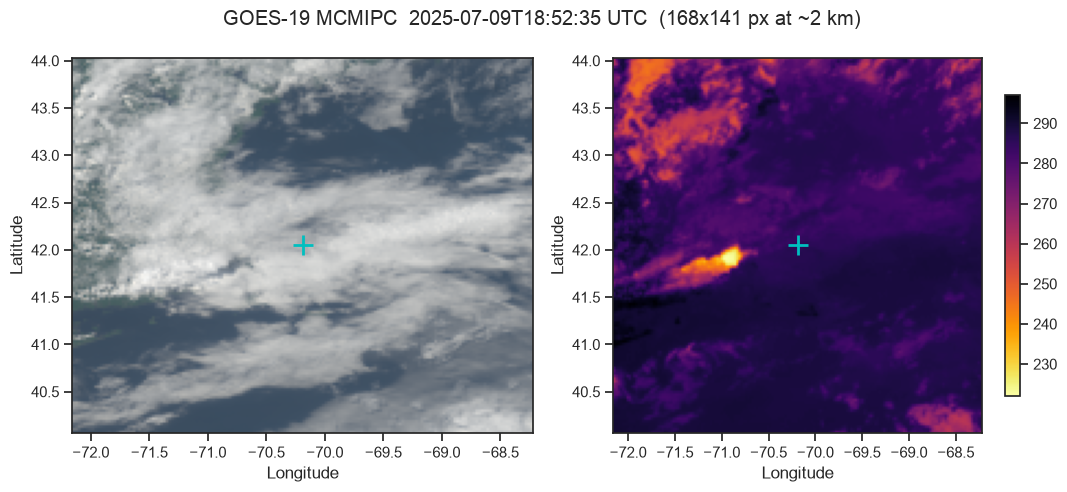

In [7]:
def true_color(ds):
    """Approximate true color from ABI bands 1 (blue), 2 (red), 3 (veggie)."""
    r, b, veg = ds["CMI_C02"].values, ds["CMI_C01"].values, ds["CMI_C03"].values
    g = 0.45 * r + 0.10 * veg + 0.45 * b          # synthetic green band
    rgb = np.dstack([np.clip(r, 0, 1), np.clip(g, 0, 1), np.clip(b, 0, 1)])
    return np.nan_to_num(rgb) ** (1 / 2.2)         # gamma brightening

def latlon_extent(ds):
    """[lon_w, lon_e, lat_s, lat_n] of the cropped grid, from the GOES projection."""
    p = ds["goes_imager_projection"].attrs
    h = p["perspective_point_height"]
    proj = Proj(proj="geos", h=h, lon_0=p["longitude_of_projection_origin"],
                sweep=p["sweep_angle_axis"], a=p["semi_major_axis"], b=p["semi_minor_axis"])
    x, y = ds.x.values * h, ds.y.values * h
    lon_w, lat_n = proj(x.min(), y.max(), inverse=True)
    lon_e, lat_s = proj(x.max(), y.min(), inverse=True)
    return [lon_w, lon_e, lat_s, lat_n]

def plot_goes(ds, point=COORDS, label=""):
    if "t" in ds.dims:                      # several scans: use the first
        ds = ds.isel(t=0)
    extent = latlon_extent(ds)
    when = str(np.datetime_as_string(ds.t.values, unit="s")) if "t" in ds else ""

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].imshow(true_color(ds), extent=extent, aspect="auto")

    im = axes[1].imshow(ds["CMI_C13"].values, extent=extent, aspect="auto", cmap="inferno_r")
    fig.colorbar(im, ax=axes[1], shrink=0.8)

    for ax in axes:
        ax.plot(point[1], point[0], "c+", ms=14, mew=2)
        ax.annotate(label, (point[1], point[0]), xytext=(6, 6),
                    textcoords="offset points", color="cyan", fontsize=9)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    ny, nx = ds.CMI_C02.shape
    fig.suptitle(f"GOES-{SATELLITE} MCMIPC  {when} UTC  ({nx}x{ny} px at ~2 km)")
    fig.tight_layout()
    plt.show()

plot_goes(ds)

## EarthCARE

EarthCARE passes over a given spot only every few days, so use a wide window. Needs the ESA MAAP credentials setup (see top).

Generate a data access token https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/auth?response_type=code&scope=openid&client_id=esa-maap-portal&state=mCLM6Y2wp0UfEeLJZluHNDPie9Q&redirect_uri=https%3A%2F%2Fportal.maap.eo.esa.int%2Fini%2Fservices%2Freg%2Fesamaap%2F&nonce=B4kWsqyo_gfiJJlHN00Sj9YDQAucmsTZhF9kyW-YKbU&code_challenge=oVPsWHZ1a3r7c08qGB3USl2qV8g-HgyzbIqm2l519ug&code_challenge_method=S256

In [8]:
eck.set_config("../.earthcare_config/default_config.toml") # point to the example configuration file

ec = EarthCareSource(file_type="ATL_NOM_1B", baseline="BA", data_dir='../data/earthcare/data')

ec_avail = ec.availability(window, region)
ec_avail.table.head()

Default config set at </Users/julianfontes/.config/earthcarekit/default_config.toml>
bb=(40.05, -72.19, 44.05, -68.19)


,mission_id,agency,latency,baseline,file_type,start_sensing_time,start_processing_time,orbit_number,frame_id,orbit_and_frame,filename,filepath,hdr_filepath,start_latitude,start_longitude,end_latitude,end_longitude,url_download_h5,url_download_hdr,url_quicklook
0,ECA,E,X,BA,ATL_NOM_1B,2025-07-09 18:50:48,2025-07-09 20:26:02,6330,D,06330D,ECA_EXBA_ATL_NOM_1B_20250709T185048Z_20250709T...,,,67.690704,-56.203056,22.666199,-73.57126,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...


In [9]:
ec_files = ec.fetch(window, region)

bb=(40.05, -72.19, 44.05, -68.19)


In [10]:
files = eck.search_product(
    path_to_data='../data/earthcare',
    file_type="ATL_NOM_1B",
    baseline="BA"
)

files

,mission_id,agency,latency,baseline,file_type,start_sensing_time,start_processing_time,orbit_number,frame_id,orbit_and_frame,filename,filepath,hdr_filepath,start_latitude,start_longitude,end_latitude,end_longitude,url_download_h5,url_download_hdr,url_quicklook
0,ECA,E,X,BA,ATL_NOM_1B,2025-07-02 06:00:30,2025-07-02 08:03:34,6213,B,06213B,ECA_EXBA_ATL_NOM_1B_20250702T060030Z_20250702T...,/Users/julianfontes/Library/Mobile Documents/c...,/Users/julianfontes/Library/Mobile Documents/c...,NaN,NaN,NaN,NaN,None,None,None
1,ECA,E,X,BA,ATL_NOM_1B,2025-07-09 18:50:48,2025-07-09 20:26:02,6330,D,06330D,ECA_EXBA_ATL_NOM_1B_20250709T185048Z_20250709T...,/Users/julianfontes/Library/Mobile Documents/c...,/Users/julianfontes/Library/Mobile Documents/c...,NaN,NaN,NaN,NaN,None,None,None


QuicklookFigure(fig=<Figure size 1791.34x1619.84 with 30 Axes>, subfigs=[[<earthcarekit.plot.figure.map.MapFigure object at 0x13b76e900>, <earthcarekit.plot.figure.map.MapFigure object at 0x13bb8a270>], [<earthcarekit.plot.figure.curtain.CurtainFigure object at 0x13bb89010>, <earthcarekit.plot.figure.curtain.CurtainFigure object at 0x34f6c6490>, <earthcarekit.plot.figure.curtain.CurtainFigure object at 0x311040690>, <earthcarekit.plot.figure.curtain.CurtainFigure object at 0x13f328cd0>], [], [<earthcarekit.plot.figure.profile.ProfileFigure object at 0x13f4fee40>, <earthcarekit.plot.figure.profile.ProfileFigure object at 0x13f61f890>, <earthcarekit.plot.figure.profile.ProfileFigure object at 0x13f61ee90>, <earthcarekit.plot.figure.profile.ProfileFigure object at 0x13f61cb90>]])

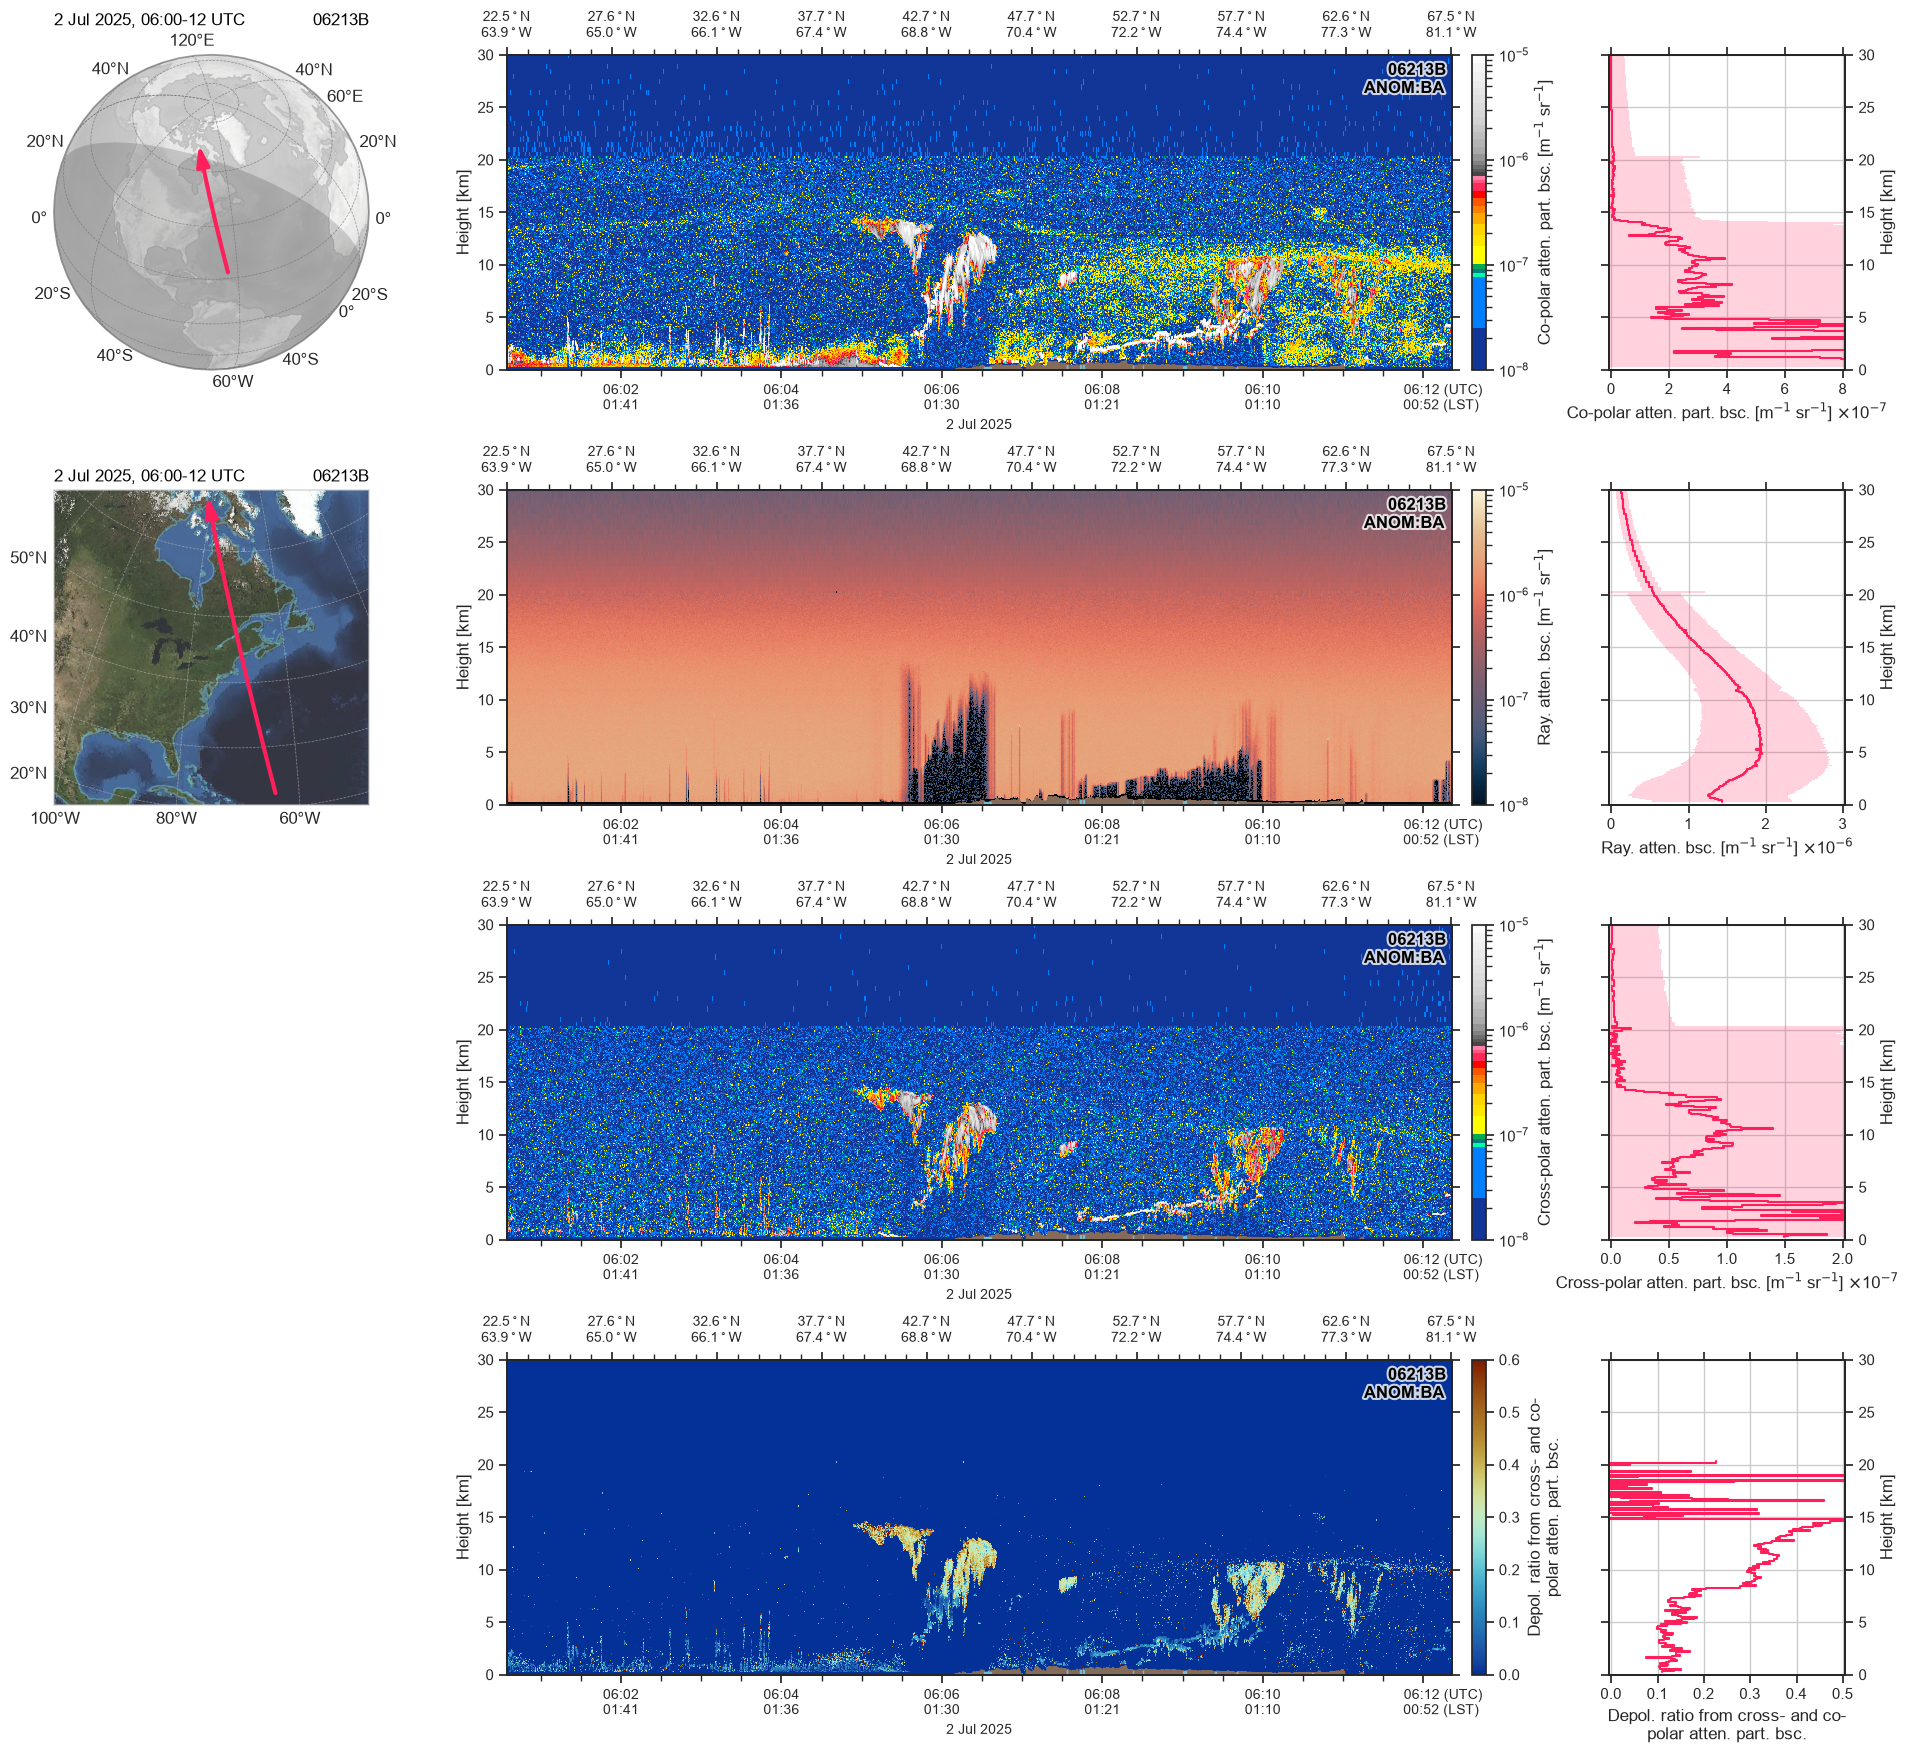

In [11]:
filepath = files.filepath[0]

eck.ecquicklook(filepath)